# Applied Nuclear Data Assimilation using GLLS

This example demonstrates the use of the **Generalized Least Squares (GLLS)** method to improve the prediction of an integral application using experimental benchmark data. 

Benchmarks:
- HMF001 
- HMF002-001

Application:
- HMF002-002

### 1. Setup and Imports
We use `andalus` for the assimilation logic and `matplotlib` for visualization, `pandas` is used to interact with the data.

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

import andalus

### 2. Reading Serpent Output
We use the `AssimilationSuite.from_yaml` method to easily load in a set of benchmarks / applications and covariance information. 

The `config.yaml` file specifies which isotopes and reactions to include in the analysis.

In [14]:
!cat "config.yaml"

# Global settings for the analysis
covariances:
  file_path: "../data/covariances_test.h5"
  nuclear_data_library: "TEST"

# List of benchmarks to be loaded into the BenchmarkSuite
benchmarks:
  - title: "HMF001"
    description: "A bare, highly enriched uranium sphere (GODIVA)."
    m: 1.00000
    dm: 0.00100
    kind: "keff"
    sens0_path: "../data/hmf001.ser_sens0.m"
    results_path: "../data/hmf001.ser_res.m"

  - title: "HMF002-001"
    description: "Topsy 8-inch tuballoy reflected oralloy assemblies (sphere)."
    m: 1.00000
    dm: 0.00300
    kind: "keff"
    sens0_path: "../data/hmf002-001.ser_sens0.m"
    results_path: "../data/hmf002-001.ser_res.m"

applications:
  - title: "HMF002-002"
    description: "Topsy 8-inch tuballoy reflected oralloy assemblies (cylinder)."
    sens0_path: "../data/hmf002-002.ser_sens0.m"
    results_path: "../data/hmf002-002.ser_res.m"


In [15]:
assimilation_suite = andalus.AssimilationSuite.from_yaml("config.yaml")

Reading ../data/hmf001.ser_res.m
  - done
Reading ../data/hmf001.ser_sens0.m
  - done
Reading ../data/hmf002-001.ser_res.m
  - done
Reading ../data/hmf002-001.ser_sens0.m
  - done
Reading ../data/hmf002-002.ser_res.m
  - done
Reading ../data/hmf002-002.ser_sens0.m
  - done


### 3. Energy-Dependent Sensitivities
Visualizing the sensitivity profiles helps us understand which energy ranges drive the $k_{\text{eff}}$ response. Below we compare U-235 fission (MT 18) sensitivities across all systems.

C:\Users\dhouben\Documents\andalus\src\andalus\sensitivity.py:230: PerformanceWarning: indexing past lexsort depth may impact performance.
  subset = self.loc[zai, pert]


[(100.0, 20000000.0)]

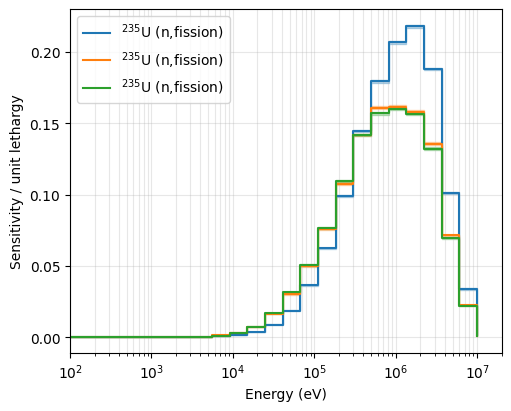

In [16]:
zais = [922350]  # U-235
perts = [18]  # Fission (MT 18)

fig, ax = plt.subplots(figsize=(5, 4), layout="constrained")

for benchmark in assimilation_suite.benchmarks:
    benchmark.s.plot_sensitivity(zais=zais, perts=perts, ax=ax)

assimilation_suite.applications["HMF002-002"].s.plot_sensitivity(zais=zais, perts=perts, ax=ax)

ax.set(
    xlim=(1e2, 2e7),
)

### 4. Similarity Analysis ($c_k$ Index)
The $c_k$ index quantifies the correlation between systems based on shared nuclear data uncertainties. 

$$
c_k=\frac{\text{Cov}(1,2)}{\sqrt(\text{Var}(1)\text{Var}(2))}
$$

Values close to 1.0 indicate that the benchmark is an excellent surrogate for the application.

In [17]:
# Print the ck-similarity matrix
ck_matrix = assimilation_suite.ck_matrix()
print(ck_matrix)

                HMF001  HMF002-001  HMF002-002
HMF001     1.00000e+00 8.58986e-01 8.61173e-01
HMF002-001 8.58986e-01 1.00000e+00 9.99814e-01
HMF002-002 8.61173e-01 9.99814e-01 1.00000e+00


In [18]:
# Print the ck-similarity values for a specific target
ck_target = assimilation_suite.ck_target("HMF002-002")
print(ck_target)

HMF001       8.61173e-01
HMF002-001   9.99814e-01
Name: HMF002-002, dtype: float64


We can see that HMF002-001 has more than 99% of the nuclear data uncertainties with regards to keff in common, meaning that if we reduce the nuclear data uncertainties in HMF002-001, we will also reduce the uncertainty in predicting keff with regards to the uncertainties due to nuclear data in HMF002-002.

### 5. Performing the GLLS Adjustment
We now calculate the posterior suite. This updates the nominal values ($c$) and reduces the covariance matrix based on the experimental evidence from the benchmarks.

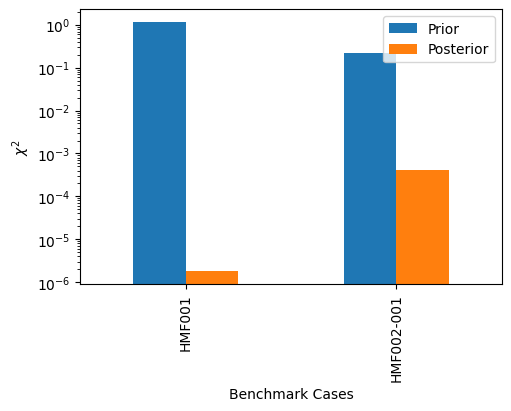

In [19]:
posterior_suite = assimilation_suite.glls()

# Compare Chi-Squared reduction
chi_comparison = pd.DataFrame(
    {
        "Prior": assimilation_suite.individual_chi_squared(nuclear_data=False),
        "Posterior": posterior_suite.individual_chi_squared(nuclear_data=False),
    }
)

fig, ax = plt.subplots(figsize=(5, 4), layout="constrained")

chi_comparison.plot.bar(ax=ax)

ax.set(
    yscale="log",
    ylabel="$\\chi^2$",
    xlabel="Benchmark Cases",
)

plt.show()

### 6. Summary of Results
The plot below shows the $k_{\text{eff}}$ predictions. Note how the **Posterior** values for the target application (HMF002-002) move significantly closer to the experimental measurement, even though that specific system was not used in the adjustment. This is because HMF002-002 is highly similar to HMF002-001, therefore correcting for the behaviour of one improves the prediction for the behaviour of the other one as well.

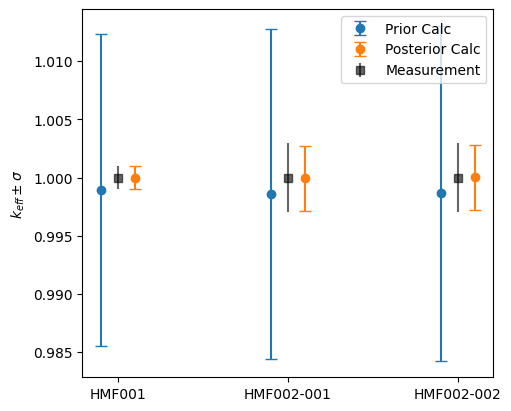

In [20]:
prior_unc = assimilation_suite.propagate_nuclear_data_uncertainty()
post_unc = posterior_suite.propagate_nuclear_data_uncertainty()

fig, ax = plt.subplots(figsize=(5, 4), dpi=100, layout="constrained")

x = range(len(assimilation_suite.titles))
ax.errorbar([i - 0.1 for i in x], assimilation_suite.c, yerr=prior_unc, fmt="o", capsize=4, label="Prior Calc")
ax.errorbar([i + 0.1 for i in x], posterior_suite.c, yerr=post_unc, fmt="o", capsize=4, label="Posterior Calc")

# Add experimental measurements (benchmarks + application)
# The final value [1.00000] and uncertainty [0.00300] represent the target application (HMF002-002)
measurement_values = assimilation_suite.benchmarks.m.tolist() + [1.00000]
measurement_uncertainties = assimilation_suite.benchmarks.dm.tolist() + [0.00300]
ax.errorbar(
    x,
    measurement_values,
    yerr=measurement_uncertainties,
    fmt="s",
    color="black",
    label="Measurement",
    alpha=0.6,
)

ax.set_xticks(x)
ax.set_xticklabels(assimilation_suite.titles)
ax.set_ylabel("$k_{eff} \\pm \\sigma$")
ax.legend()
plt.show()